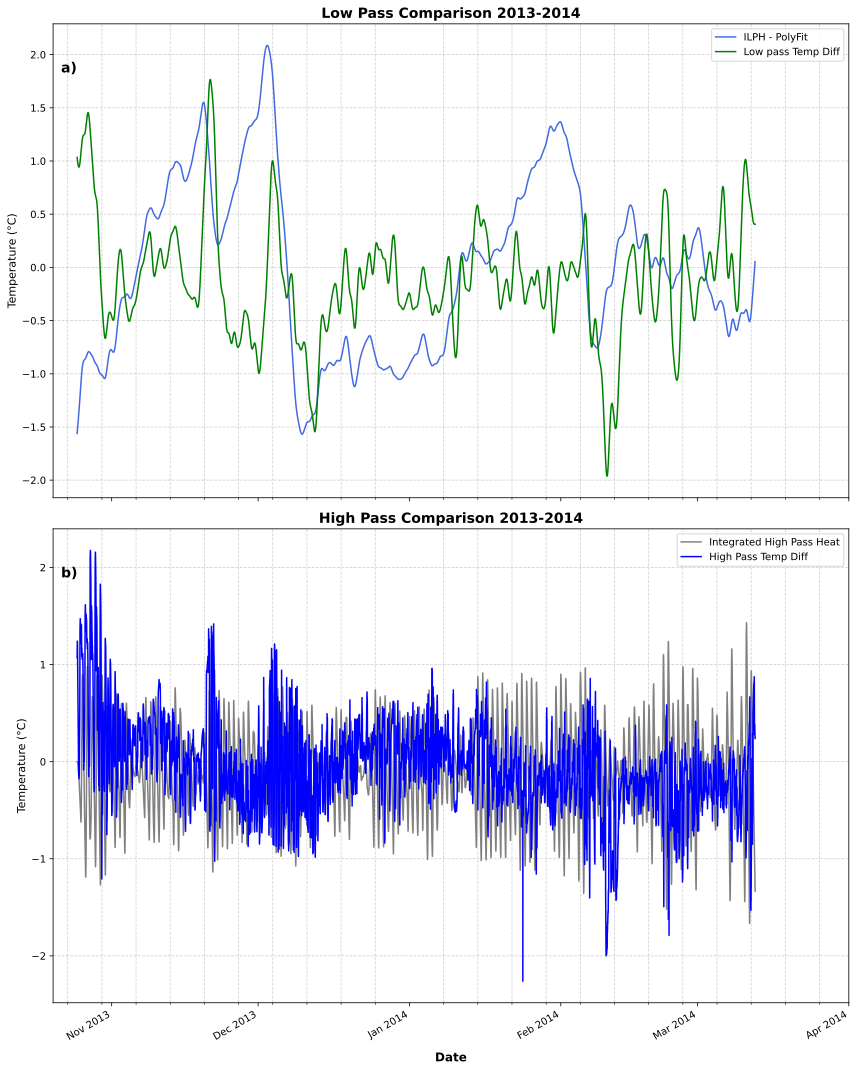

In [3]:
import datetime
import re
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy import integrate, signal, stats

# Enable vector graphics rendering
%config InlineBackend.figure_format = 'svg'

# --- Load Data ---
predictedSMidDF = pd.read_csv("surface_temperature_model_mid13-14.csv", parse_dates=["DN"])
predictedBMidDF = pd.read_csv("bottom_temperature_model_mid13-14.csv", parse_dates=["DN"])
heatMidDF = pd.read_csv("mid_heatflux_2013-2014.csv", parse_dates=["Tm (UTC)"])

heatMidDF.loc[heatMidDF.index <= 18, "Qnet"] = heatMidDF["Qnet"].iloc[19]
heatMidDF.loc[heatMidDF.index >= heatMidDF.shape[0] - 18, "Qnet"] = heatMidDF["Qnet"].iloc[heatMidDF.shape[0] - 19]
heatMidDF = pd.merge(predictedSMidDF, heatMidDF, how="left", left_on="DN", right_on="Tm (UTC)")[["Qnet"]]
heatMidDF = heatMidDF.interpolate().bfill().ffill()

riverDF = pd.read_csv("river_temperature_interpol13_14.csv", parse_dates=["DN"])
riverDF = pd.merge_asof(predictedSMidDF, riverDF, left_on="DN", right_on="DN")[["EstimatedTemp"]]

# --- Butterworth Filtering ---
fs = 288  # Sampling frequency
fcHighpass = 24 / 36  # Cut-off frequency of the filter
wHighpass = fcHighpass / (fs / 2)  # Normalize frequency

surfaceDF = pd.DataFrame({"T": predictedSMidDF["TempDiff"]})
bottomDF = pd.DataFrame({"T": predictedBMidDF["TempDiff"]})
heatDF = pd.DataFrame({"T": heatMidDF["Qnet"]})

surfaceAdjustedTemp = surfaceDF["T"].interpolate().bfill().ffill().to_numpy()
bottomAdjustedTemp = bottomDF["T"].interpolate().bfill().ffill().to_numpy()
heatAdjusted = heatDF["T"].interpolate().bfill().ffill().to_numpy()

surfaceLowpass = signal.butter(4, wHighpass, "lowpass", analog=False, output="sos")
bottomLowpass = signal.butter(4, wHighpass, "lowpass", analog=False, output="sos")
heatLowpass = signal.butter(4, wHighpass, "lowpass", analog=False, output="sos")

outputSurfaceLow = signal.sosfiltfilt(surfaceLowpass, surfaceAdjustedTemp)
outputSurfaceHigh = outputSurfaceLow - predictedBMidDF["TempDiff"]
outputBottomLow = signal.sosfiltfilt(bottomLowpass, bottomAdjustedTemp)
outputHeatLow = signal.sosfiltfilt(heatLowpass, heatAdjusted)

outputHeatLowAdjusted = outputHeatLow
outputHeatHigh = heatMidDF["Qnet"] - outputHeatLow

# --- Physical Integration & Fitting ---
heatModelHigh = outputHeatHigh / (1025 * 4010 * 0.8)
heatModelLow = outputHeatLowAdjusted / (1025 * 4010 * 4.7)

integratedHighModel = integrate.cumulative_trapezoid(heatModelHigh, initial=0, dx=300)
integratedLowModel = integrate.cumulative_trapezoid(heatModelLow, initial=0, dx=300)

dn_int64 = predictedSMidDF["DN"].astype(np.int64)
polynomialFitLowPass = np.polyval(np.polyfit(dn_int64, integratedLowModel, deg=3), dn_int64)
finalizedLowModel = integratedLowModel - polynomialFitLowPass

# Export CSV
highPassTestDF = pd.DataFrame({"DN": predictedSMidDF["DN"], "Integrated Highpass": integratedHighModel, "TempDiff": outputSurfaceHigh})
highPassTestDF.to_csv("midestuary_highpass_13_14.csv", index=False)

# =========================================================================
# Matplotlib 2-Subplot Figure
# =========================================================================
fig, axs = plt.subplots(2, 1, figsize=(12, 15), sharex=True)
axs[0].set_xlim(pd.Timestamp("2013-10-20 00:00:00"), pd.Timestamp("2014-04-01 00:00:00"))

# 1. Low Pass Comparison
axs[0].plot(predictedSMidDF["DN"], finalizedLowModel, label="ILPH - PolyFit", color="royalblue")
axs[0].plot(predictedSMidDF["DN"], outputSurfaceLow, label="Low pass Temp Diff", color="green")
axs[0].set_title("Low Pass Comparison 2013-2014", fontsize=14, fontweight="bold")
axs[0].set_ylabel("Temperature (°C)", fontsize=11)
axs[0].legend(loc="upper right", frameon=True)
axs[0].text(0.01, 0.92, "a)", transform=axs[0].transAxes, fontsize=14, fontweight="bold", va="top")

# 2. High Pass Comparison
axs[1].plot(predictedSMidDF["DN"], integratedHighModel, label="Integrated High Pass Heat", color="gray")
axs[1].plot(predictedSMidDF["DN"], outputSurfaceHigh, label="High Pass Temp Diff", color="blue")
axs[1].set_title("High Pass Comparison 2013-2014", fontsize=14, fontweight="bold")
axs[1].set_ylabel("Temperature (°C)", fontsize=11)
axs[1].legend(loc="upper right", frameon=True)
axs[1].text(0.01, 0.92, "b)", transform=axs[1].transAxes, fontsize=14, fontweight="bold", va="top")
# Styling and Date Formatting
for ax in axs:
    ax.grid(True, which='major', axis = 'y', linestyle='--', alpha=0.6)
    
    # 7-day interval for minor vertical gridlines along the x-axis
    ax.xaxis.set_minor_locator(mdates.DayLocator(interval=7))
    ax.grid(True, which='minor', axis='x', linestyle='--', alpha=0.6)
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
fig.autofmt_xdate()


axs[1].set_xlabel("Date", fontweight="bold", labelpad=10, fontsize=12)
plt.tight_layout()
plt.show()